## 0. Imports & configuration

In [41]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- paths (all relative to analysis/) ---
ROOT_FILE     = "../target_run.root"          # outputs land in launch dir = repo root
IONIZ_PATH    = "../data/TRIM/IONIZ.txt"
PHONON_PATH   = "../data/TRIM/PHONON.txt"
E2RECOIL_PATH = "../data/TRIM/E2RECOIL.txt"
TRIM_RANGE_PATH = "../data/TRIM/Range-3D.txt"

# --- constants ---
BIN_NM     = 0.5      # Geant4 H1 / mesh z-bin width [nm]
E_GATE     = 20.0     # keV, first-entry energy gate (Vacuum env, impact must be 25 KeV)
ANGLE_GATE = 5e-3     # rad = 5 mrad; 50 sigma of beam, excludes grazing re-entries
GEN = {  # generator truth (PrimaryGeneratorAction)
    "x [mm]":    (0.0, 0.5),
    "y [mm]":    (0.0, 0.5),
    "xp [mrad]": (0, 0),
    "yp [mrad]": (0, 0),
    "E [keV]":   (25.0, 0),   # sigma = E * relSigmaE = 25 * 0.01
}

## 1. Helpers

In [2]:
def h1_density(f, name, N):
    """ROOT H1 -> (bin centers [nm], dE/dz [keV/nm per ion])."""
    v, e = f[name].to_numpy()               # MeV contents, mm edges
    centers = 0.5 * (e[1:] + e[:-1]) * 1e6  # mm -> nm
    return centers, v * 1e3 / N / BIN_NM    # MeV -> keV, per ion, per nm

def parse_trim(fname, ncols, x_scale=0.1, y_scale=0.01):
    """TRIM fixed-width table -> array. Defaults: depth A->nm, eV/(A ion) -> keV/(nm ion).
    Col 0 gets x_scale, the rest y_scale. Handles Fortran '2.53-01' exponents."""
    rows = []
    with open(fname, encoding="latin-1") as fh:
        for line in fh:
            parts = line.replace(",", " ").split()
            try:
                vals = []
                for p in parts:
                    if "E" not in p.upper() and ("-" in p[1:] or "+" in p[1:]):
                        i = max(p.rfind("+"), p.rfind("-"))
                        p = p[:i] + "E" + p[i:]
                    vals.append(float(p))
                if len(vals) == ncols:
                    rows.append(vals)
            except ValueError:
                continue
    d = np.array(rows)
    d[:, 0]  *= x_scale
    d[:, 1:] *= y_scale
    return d

def median_depth(z, dens):
    """Depth containing 50% of the integral (robust stretch metric)."""
    c = np.cumsum(dens)
    return z[np.searchsorted(c, 0.5 * c[-1])]

def integral(z, dens):
    """Total keV/ion under a density curve."""
    return float(np.sum(dens) * np.diff(z).mean())

def parse_trim_range_matrix(fname):
    """SRIM Ion-Distribution matrix: col 0 = depth [A], cols 1..100 = lateral bins.
    Returns (depth centers [nm], lateral-integrated weights)."""
    rows = []
    with open(fname, encoding="latin-1") as fh:
        for line in fh:
            try:
                vals = [float(p) for p in line.split()]
                if len(vals) == 101:
                    rows.append(vals)
            except ValueError:
                continue
    d = np.array(rows)
    return d[:, 0] * 0.1, d[:, 1:].sum(axis=1)

## 2. Load Geant4 output, derive N (Account Rejected/Gated)

In [29]:
f = uproot.open(ROOT_FILE)
b = f["beam"].arrays(library="np")

gate = (b["E"] > E_GATE) & (np.abs(b["xp"]) < ANGLE_GATE) & (np.abs(b["yp"]) < ANGLE_GATE)
N = int(gate.sum())
n_rejected = len(b["E"]) - N
print(f"primaries (gated first entries): N = {N}")
print(f"rejected (Angle & Energy Gate): {n_rejected} ({100*n_rejected/len(b['E']):.2f}%)")

primaries (gated first entries): N = 10000
rejected (Angle & Energy Gate): 59 (0.59%)


## 3. Beam verification: input vs output
Gaussian fits of the entry-plane state against generator truth. Standard error of a fitted sigma ~ sigma/sqrt(2N) (~1% at N=10^4): agreement means within a few SE.

In [27]:
data = {
    "x [mm]":    b["x"][gate],
    "y [mm]":    b["y"][gate],
    "xp [mrad]": b["xp"][gate] * 1e3,
    "yp [mrad]": b["yp"][gate] * 1e3,
    "E [keV]":   b["E"][gate],
}

print(f"{'qty':10s} {'gen mu':>8s} {'gen sig':>8s} {'fit mu':>8s} {'fit sig':>8s} {'SE(sig)':>8s}")
for k, (gmu, gsig) in GEN.items():
    mu, sig = norm.fit(data[k])
    se = gsig / np.sqrt(2 * N)
    print(f"{k:10s} {gmu:8.3f} {gsig:8.3f} {mu:8.3f} {sig:8.3f} {se:8.4f}")

qty          gen mu  gen sig   fit mu  fit sig  SE(sig)
x [mm]        0.000    0.500   -0.005    0.500   0.0035
y [mm]        0.000    0.500   -0.001    0.504   0.0035
xp [mrad]     0.000    0.000    0.000    0.000   0.0000
yp [mrad]     0.000    0.000    0.000    0.000   0.0000
E [keV]      25.000    0.000   25.000    0.000   0.0000


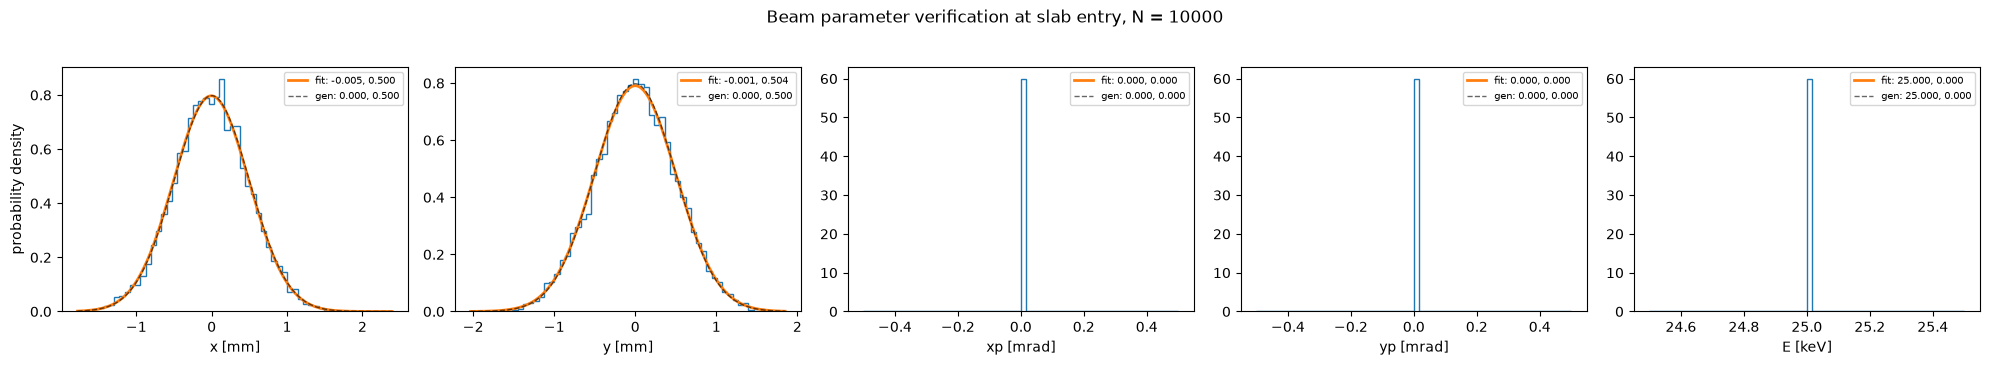

In [28]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
for ax, (k, (gmu, gsig)) in zip(axes, GEN.items()):
    d = data[k]
    mu, sig = norm.fit(d)
    n, bins, _ = ax.hist(d, bins=60, density=True, histtype="step", color="C0")
    xs = np.linspace(bins[0], bins[-1], 300)
    ax.plot(xs, norm.pdf(xs, mu, sig), "C1-", lw=2, label=f"fit: {mu:.3f}, {sig:.3f}")
    ax.plot(xs, norm.pdf(xs, gmu, gsig), "k--", lw=1, alpha=0.6, label=f"gen: {gmu:.3f}, {gsig:.3f}")
    ax.set_xlabel(k); ax.legend(fontsize=7)
axes[0].set_ylabel("probability density")
fig.suptitle(f"Beam parameter verification at slab entry, N = {N}", y=1.03)
plt.tight_layout(); plt.show()

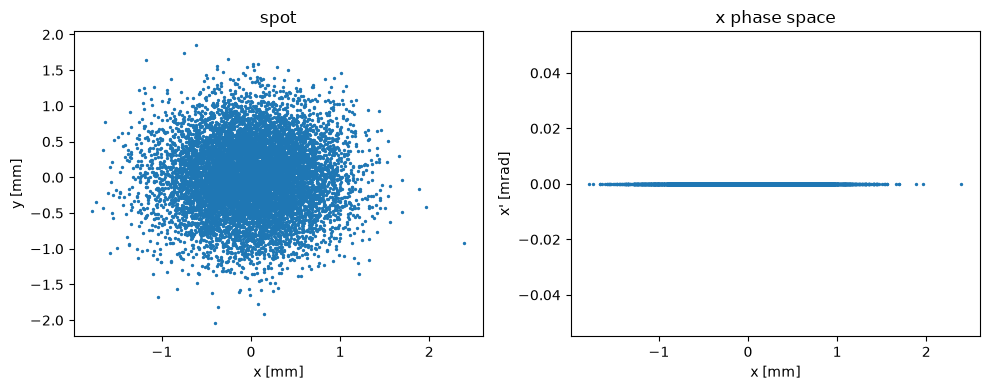

In [ ]:
# spot + phase space (gated by impact energy)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(data["x [mm]"], data["y [mm]"], s=2)
ax[0].set(xlabel="x [mm]", ylabel="y [mm]", title="spot")
ax[1].scatter(data["x [mm]"], data["xp [mrad]"], s=2)
ax[1].set(xlabel="x [mm]", ylabel="x' [mrad]", title="x phase space")
plt.tight_layout(); plt.show()

## 4. Energy deposition: manual scorer vs mesh.

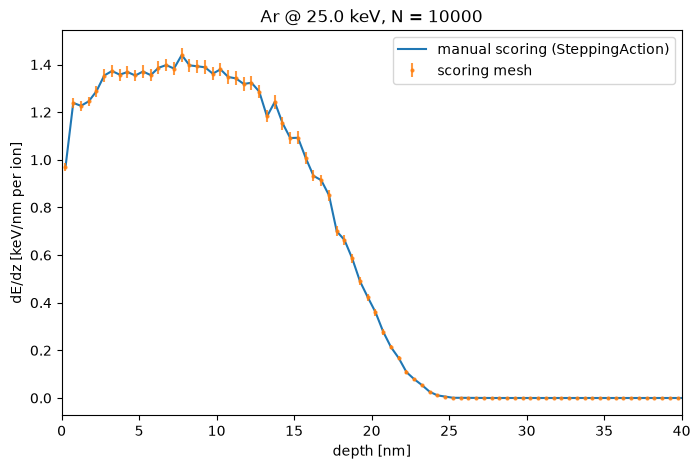

manual integral:  24.140 keV/ion
mesh   integral:  24.140 keV/ion
max |resid| = 0.0007 keV/nm


In [17]:
z_g, tot_g = h1_density(f, "EdepZ", N)

d = np.loadtxt("../edep_mesh.csv", delimiter=",", comments="#")
iz = d[:, 2].astype(int); order = np.argsort(iz)
mesh_keV_bin = d[order, 3] / N                 # keV per ion per bin
mesh_dens    = mesh_keV_bin / BIN_NM           # -> keV/nm per ion
mesh_z       = (iz[order] + 0.5) * BIN_NM
sum_v, sum_v2, n_ent = d[order, 3], d[order, 4], d[order, 5]
with np.errstate(invalid="ignore", divide="ignore"):
    sigma = np.sqrt(np.maximum(sum_v2 - sum_v**2 / np.maximum(n_ent, 1), 0)) / N / BIN_NM

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(z_g, tot_g, "C0-", label="manual scoring (SteppingAction)")
ax.errorbar(mesh_z, mesh_dens, yerr=sigma, fmt=".", ms=4, color="C1", alpha=0.8, label="scoring mesh")
ax.set(xlabel="depth [nm]", ylabel="dE/dz [keV/nm per ion]", xlim=(0, 40))
ax.legend(); ax.set_title(f"Ar @ {data['E [keV]'].mean():.1f} keV, N = {N}")
plt.show()

print(f"manual integral: {integral(z_g, tot_g):7.3f} keV/ion")
print(f"mesh   integral: {integral(mesh_z, mesh_dens):7.3f} keV/ion")
resid = tot_g - mesh_dens
chi = resid / np.where(sigma > 0, sigma, np.inf)
print(f"max |resid| = {np.abs(resid).max():.4f} keV/nm")

## 5. TRIM channels & totals vs Geant4

In [55]:
ioniz    = parse_trim(IONIZ_PATH, 3)
phonon   = parse_trim(PHONON_PATH, 3)
e2recoil = parse_trim(E2RECOIL_PATH, 3)

z_t = ioniz[:, 0]
assert np.allclose(z_t, phonon[:, 0]) and np.allclose(z_t, e2recoil[:, 0])

ioniz_ions, ioniz_rec = ioniz[:, 1], ioniz[:, 2]
phonon_tot = phonon[:, 1] + phonon[:, 2]
trim_total = ioniz_ions + ioniz_rec + phonon_tot

print("integrals [keV/ion]")
for name, c in [("IONIZ ions", ioniz_ions), ("IONIZ recoils", ioniz_rec),
                ("PHONON ions", phonon[:, 1]), ("PHONON recoils", phonon[:, 2]), ("TRIM total", trim_total),
                ("E2RECOIL (transfer)", e2recoil[:, 1])]:
    print(f"  {name:20s} {integral(z_t, c):6.2f}")
ledger = integral(z_t, ioniz_rec) + integral(z_t, phonon[:, 2])
print(f"  recoil dissipation (IONIZ by recoils+PHONON by recoils) {ledger:.2f} vs E2RECOIL {integral(z_t, e2recoil[:, 1]):.2f}")

integrals [keV/ion]
  IONIZ ions             5.61
  IONIZ recoils          7.77
  PHONON ions            0.57
  PHONON recoils        10.75
  TRIM total            24.70
  E2RECOIL (transfer)   18.70
  recoil dissipation (IONIZ by recoils+PHONON by recoils) 18.52 vs E2RECOIL 18.70


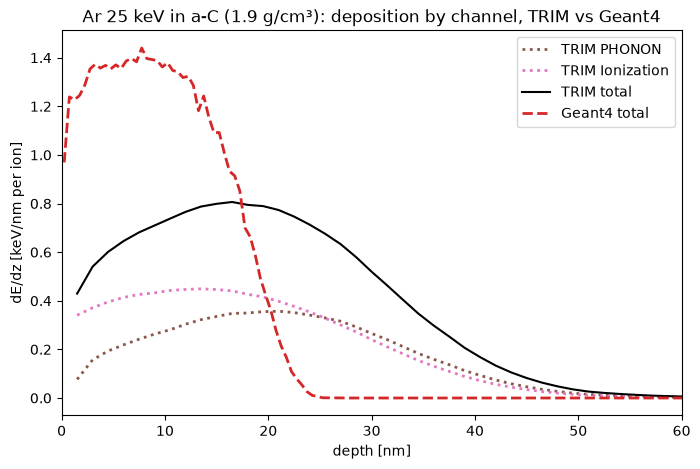

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(z_t, phonon[:, 2], "C5:", lw=2, label="TRIM PHONON")
ax.plot(z_t, ioniz_rec + ioniz_ions, "C6:", lw=2, label="TRIM Ionization")
ax.plot(z_t, trim_total, "k-", lw=1.5, label="TRIM total")
ax.plot(z_g, tot_g, "C3--", lw=2, label="Geant4 total")
ax.set(xlabel="depth [nm]", ylabel="dE/dz [keV/nm per ion]", xlim=(0, 60))
ax.legend(); ax.set_title("Ar 25 keV in a-C (1.9 g/cm³): deposition by channel, TRIM vs Geant4")
plt.show()

## 6. Transfer-frame channel comparison

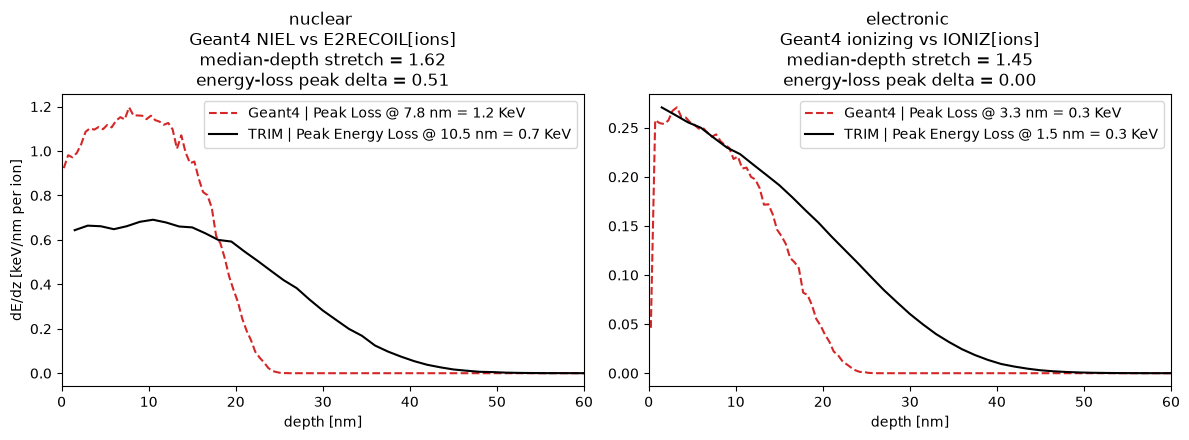

integrals [keV/ion]:
  NIEL      20.27  vs E2RECOIL[ions]  18.70
  ionizing   3.87  vs IONIZ[ions]      5.61


In [52]:
_, niel_g = h1_density(f, "EdepZ_NIEL", N)
_, ion_g  = h1_density(f, "EdepZ_ion", N)
assert np.allclose(niel_g + ion_g, tot_g, atol=1e-6), "NIEL + ionizing != total"

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
pairs = [
    (niel_g, e2recoil[:, 1], "nuclear \nGeant4 NIEL vs E2RECOIL[ions]"),
    (ion_g,  ioniz_ions,     "electronic \nGeant4 ionizing vs IONIZ[ions]"),
]
for ax, (g, t, title) in zip(axes, pairs):
    ax.plot(z_g, g, "C3--", label=f"Geant4 | Peak Loss @ {z_g[np.argmax(g)]:.1f} nm = {np.max(g):.1f} KeV")
    ax.plot(z_t, t, "k-",  label=f"TRIM | Peak Energy Loss @ {z_t[np.argmax(t)]:.1f} nm = {np.max(t):.1f} KeV")
    s = median_depth(z_t, t) / median_depth(z_g, g)
    peak_delta = np.max(g) - np.max(t)
    ax.set_title(title + f"\nmedian-depth stretch = {s:.2f}" + f"\nenergy-loss peak delta = {peak_delta:.2f}")
    ax.set_xlabel("depth [nm]"); ax.set_xlim(0, 60); ax.legend()
axes[0].set_ylabel("dE/dz [keV/nm per ion]")
plt.tight_layout(); plt.show()

print("integrals [keV/ion]:")
print(f"  NIEL     {integral(z_g, niel_g):6.2f}  vs E2RECOIL[ions] {integral(z_t, e2recoil[:, 1]):6.2f}")
print(f"  ionizing {integral(z_g, ion_g):6.2f}  vs IONIZ[ions]    {integral(z_t, ioniz_ions):6.2f}")

# 7. Range Profile Analysis

In [35]:
r = f["range"].arrays(library="np")
zg = r["zf"][r["zf"] > 0] * 1e6                 # mm -> nm, standard G4 spatial units
print(f"Geant4: Rp = {zg.mean():.1f} nm, straggle = {zg.std():.1f} nm, "
      f"backscattered = {(r['zf'] <= 0).mean()*100:.2f}%") # Filter back-scattered ions

Geant4: Rp = 13.4 nm, straggle = 5.5 nm, backscattered = 9.30%


In [36]:
# ---- stats for the legend ----
def stats(z): return z.mean(), z.std()
Rp_g, sg = stats(zg)

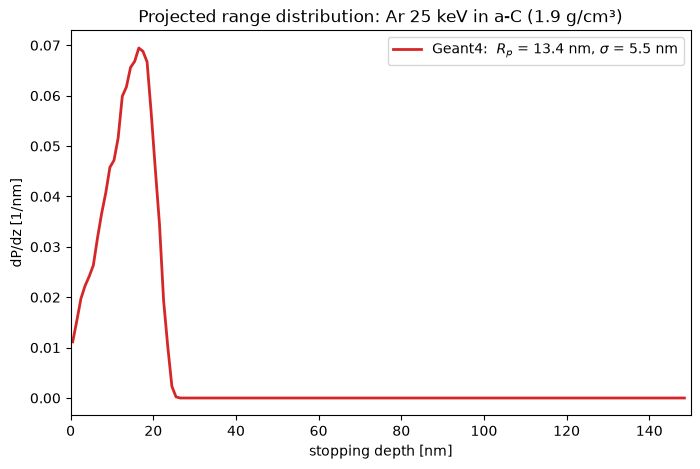

In [44]:
## ---- Plot GEANT4 Range Profile
bins_G4 = np.arange(0, 150, 1)  # 1 nm bins
fig, ax = plt.subplots(figsize=(8, 5))
c = 0.5 * (bins_G4[1:] + bins_G4[:-1])
dens_g, _ = np.histogram(zg, bins=bins_G4, density=True)
ax.plot(c, dens_g, "C3-", lw=2, label=f"Geant4:  $R_p$ = {Rp_g:.1f} nm, $\\sigma$ = {sg:.1f} nm")
ax.set(xlabel="stopping depth [nm]", ylabel="dP/dz [1/nm]",
       title="Projected range distribution: Ar 25 keV in a-C (1.9 g/cm³)")
ax.set_xlim(0, 150)
ax.legend()
plt.show()

# 8. Range Profile TRIM Comparison

In [38]:
# ---- Load Trim Range ----
zt, wt = parse_trim_range_matrix(TRIM_RANGE_PATH)

Rp_t = np.average(zt, weights=wt)
st   = np.sqrt(np.average((zt - Rp_t)**2, weights=wt)) # Compute straggle from weighted variance
dens_t = wt / wt.sum() / np.diff(zt).mean()

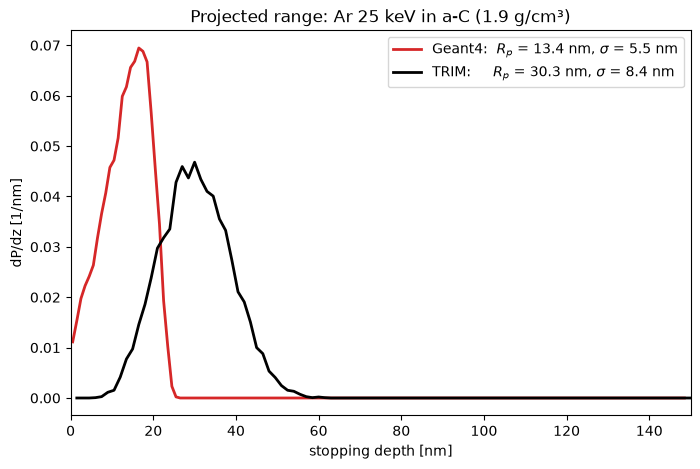

Rp ratio (TRIM/Geant4) = 2.25
relative straggle  G4: 0.41  TRIM: 0.28


In [45]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.arange(0, 150, 1)
c = 0.5 * (bins[1:] + bins[:-1])
ax.plot(c, dens_g, "C3-", lw=2, label=f"Geant4:  $R_p$ = {Rp_g:.1f} nm, $\\sigma$ = {sg:.1f} nm")
ax.plot(zt, dens_t, "k-", lw=2, label=f"TRIM:     $R_p$ = {Rp_t:.1f} nm, $\\sigma$ = {st:.1f} nm")
ax.set(xlabel="stopping depth [nm]", ylabel="dP/dz [1/nm]", xlim=(0, 150),
       title="Projected range: Ar 25 keV in a-C (1.9 g/cm³)")
ax.legend()
plt.show()

print(f"Rp ratio (TRIM/Geant4) = {Rp_t/Rp_g:.2f}")
print(f"relative straggle  G4: {sg/Rp_g:.2f}  TRIM: {st/Rp_t:.2f}")